In [ ]:
import marimo as mo

mo.md(
    """
    # Input-Dependent Observation Noise

    This notebook demonstrates the learned input-dependent observation-noise
    route. The synthetic system has a smooth latent function, while the
    measurement-noise variance increases smoothly with `x`.

    Training inputs are concentrated in the middle of the domain. This makes
    two uncertainty sources visible in prediction:

    - learned observation noise, which increases with `x`
    - latent GP uncertainty, which grows outside the training range

    The learned noise model used here is linear in `x` before the positive
    variance transform, so the data-generating noise trend is smooth rather
    than discontinuous.

    Notation used below: `D` is the training data, `x_*` is a test input,
    `f_* = f(x_*)` is the latent function value, `y_*` is a future noisy
    observation, and `sigma_obs^2(x_*)` is the learned observation-noise
    variance at that test input.
    """
)

# Input-Dependent Observation Noise

This notebook demonstrates the learned input-dependent observation-noise
route. The synthetic system has a smooth latent function, while the
measurement-noise variance increases smoothly with `x`.

Training inputs are concentrated in the middle of the domain. This makes
two uncertainty sources visible in prediction:

- learned observation noise, which increases with `x`
- latent GP uncertainty, which grows outside the training range

The learned noise model used here is linear in `x` before the positive
variance transform, so the data-generating noise trend is smooth rather
than discontinuous.

Notation used below: `D` is the training data, `x_*` is a test input,
`f_* = f(x_*)` is the latent function value, `y_*` is a future noisy
observation, and `sigma_obs^2(x_*)` is the learned observation-noise
variance at that test input.

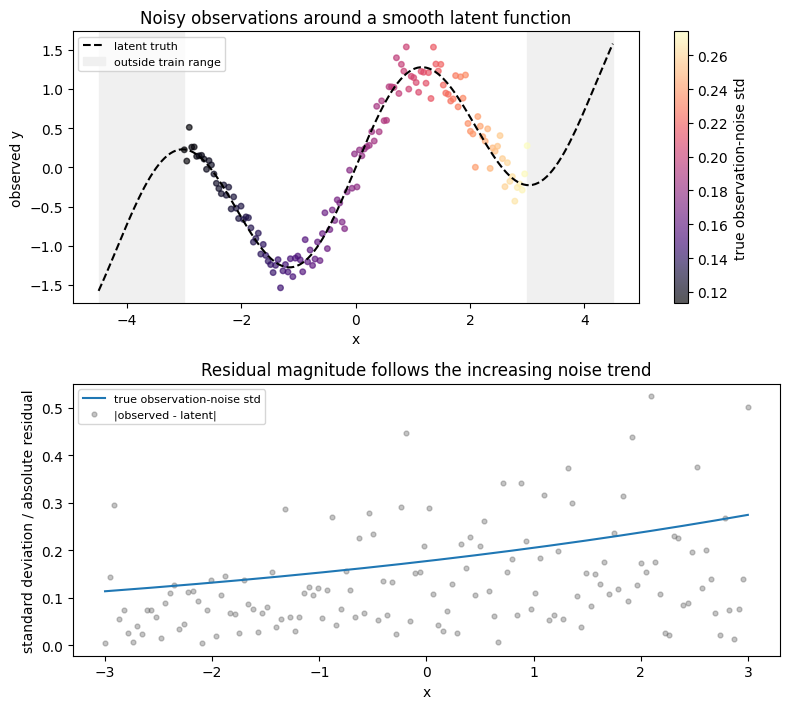

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(34)
X_train = np.linspace(-3.0, 3.0, 140, dtype=np.float32).reshape(-1, 1)
X_test = np.linspace(-4.5, 4.5, 180, dtype=np.float32).reshape(-1, 1)

def signal(X):
    return (np.sin(1.5 * X[:, 0]) + 0.25 * X[:, 0]).astype(np.float32)

def true_noise_fn(X_eval):
    x = X_eval[:, 0].astype(np.float64)
    raw_noise = -3.45 + 0.30 * x
    return (np.logaddexp(0.0, raw_noise) + 1e-6).astype(np.float32)

train_noise = true_noise_fn(X_train)
test_noise = true_noise_fn(X_test)
latent_train = signal(X_train)
y_train = (
    latent_train + rng.standard_normal(len(X_train)) * np.sqrt(train_noise)
).astype(np.float32)
y_true = signal(X_test)
train_residual_abs = np.abs(y_train - latent_train)

data_fig, data_axes = plt.subplots(2, 1, figsize=(8, 7.2))
observation_ax, residual_ax = data_axes
scatter = observation_ax.scatter(
    X_train[:, 0],
    y_train,
    c=np.sqrt(train_noise),
    cmap="magma",
    s=16,
    alpha=0.65,
)
observation_ax.plot(X_test[:, 0], y_true, "k--", label="latent truth")
observation_ax.axvspan(-4.5, -3.0, color="0.94", zorder=-1)
observation_ax.axvspan(3.0, 4.5, color="0.94", zorder=-1, label="outside train range")
observation_ax.set_title("Noisy observations around a smooth latent function")
observation_ax.set_xlabel("x")
observation_ax.set_ylabel("observed y")
observation_ax.legend(fontsize=8)
data_fig.colorbar(scatter, ax=observation_ax, label="true observation-noise std")

residual_ax.plot(
    X_train[:, 0],
    np.sqrt(train_noise),
    color="tab:blue",
    label="true observation-noise std",
)
residual_ax.scatter(
    X_train[:, 0],
    train_residual_abs,
    s=12,
    alpha=0.35,
    color="0.35",
    label="|observed - latent|",
)
residual_ax.set_title("Residual magnitude follows the increasing noise trend")
residual_ax.set_xlabel("x")
residual_ax.set_ylabel("standard deviation / absolute residual")
residual_ax.legend(fontsize=8)
data_fig.tight_layout()
mo.mpl.interactive(data_fig)

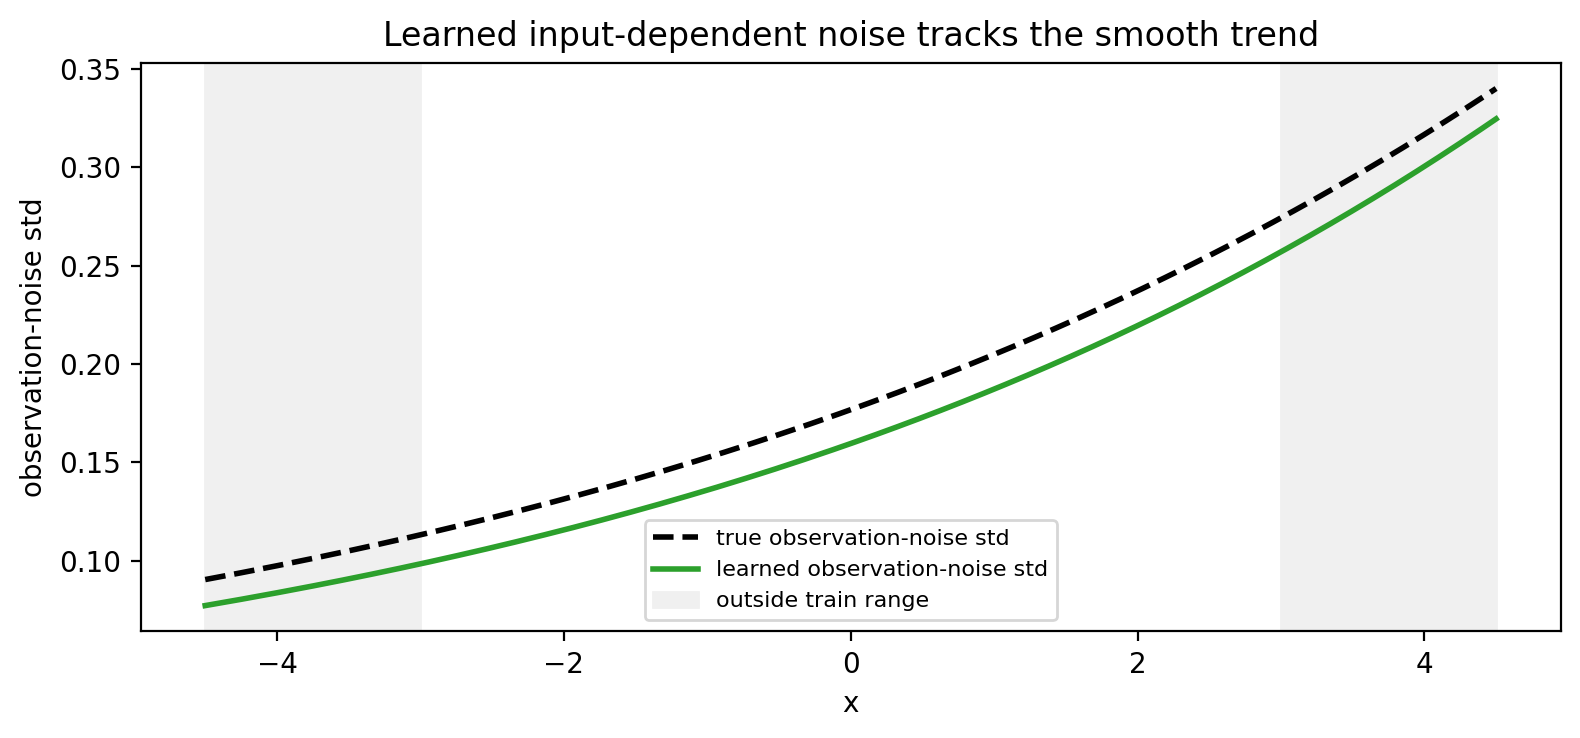

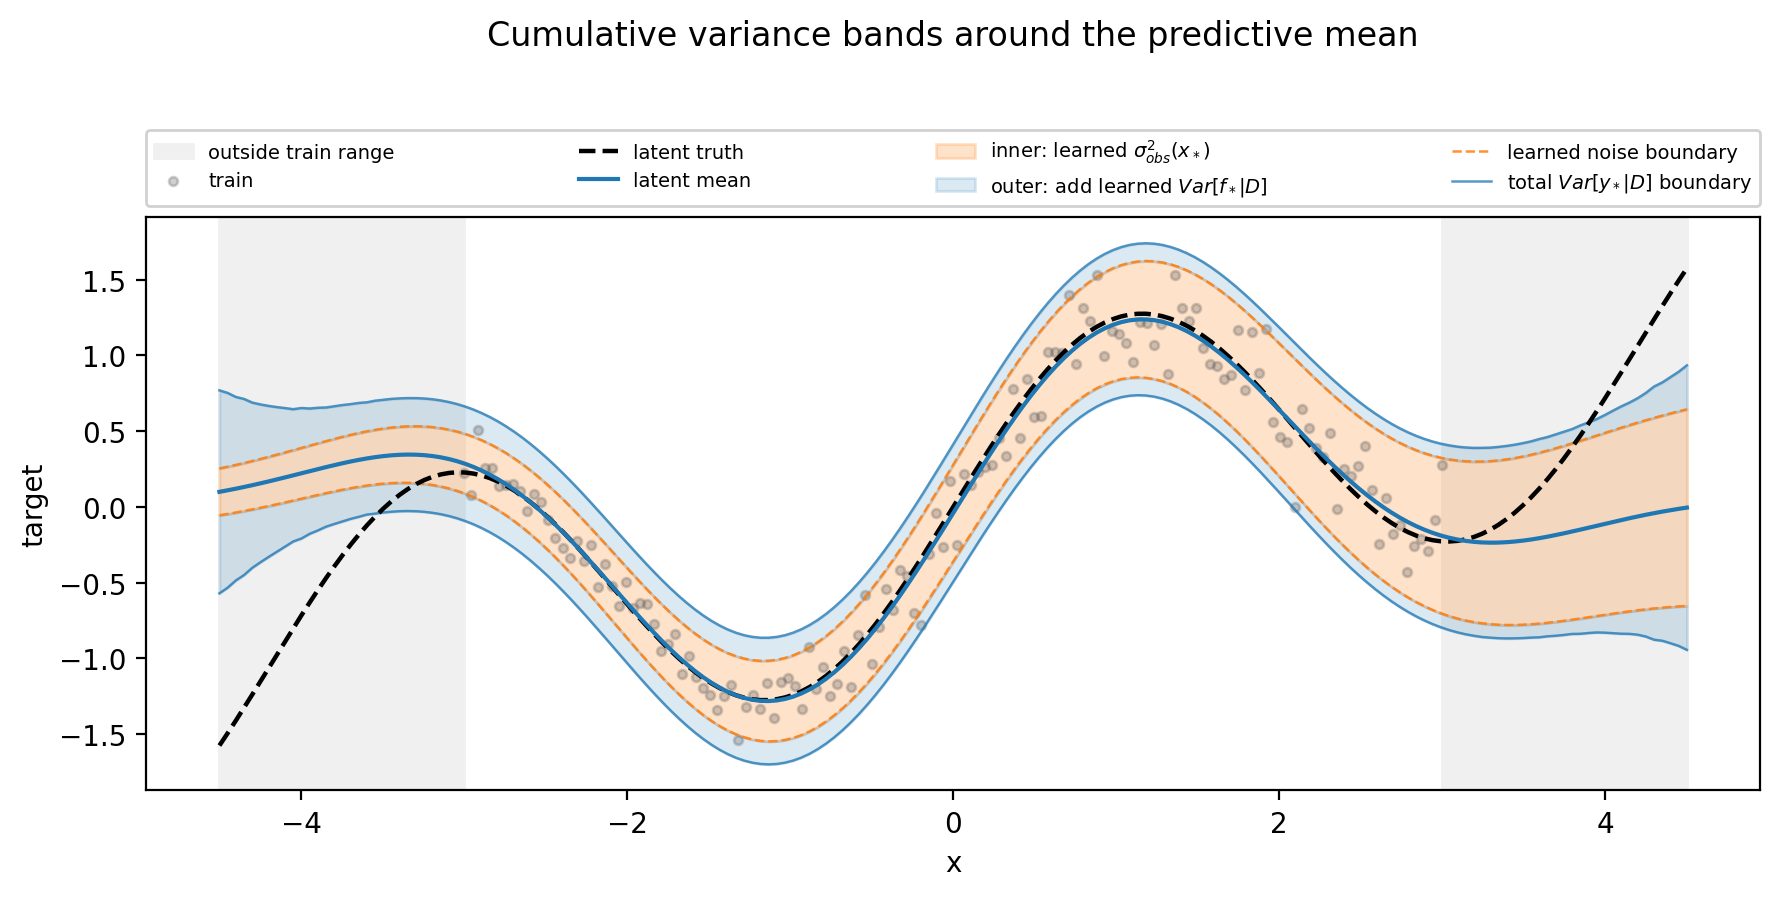

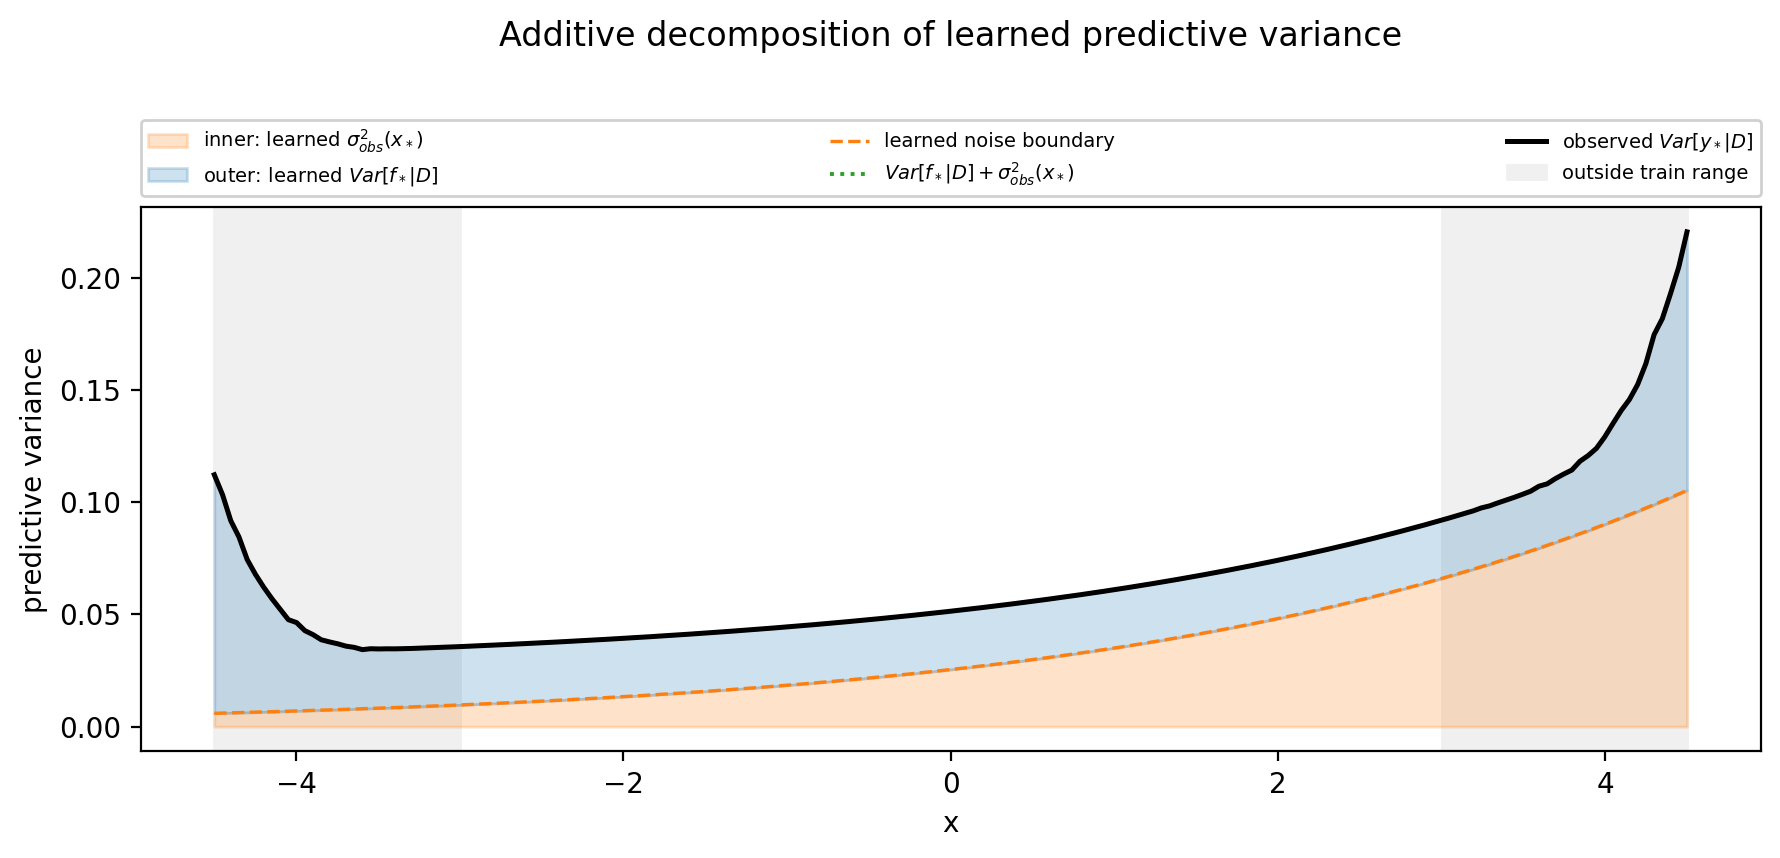

<marimo-table data-initial-value='[]' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">Learned input-dependent noise summary</span></span>"' data-data='"[{\"Quantity\":\"Predictive mean RMSE vs latent truth\",\"Value\":\"0.4876\"},{\"Quantity\":\"Noise variance RMSE vs true function\",\"Value\":\"0.00654\"},{\"Quantity\":\"Noise std RMSE vs true function\",\"Value\":\"0.01632\"},{\"Quantity\":\"Mean true noise std\",\"Value\":\"0.1897\"},{\"Quantity\":\"Mean learned noise std\",\"Value\":\"0.1734\"},{\"Quantity\":\"Mean learned latent GP std\",\"Value\":\"0.1741\"},{\"Quantity\":\"Mean observed std\",\"Value\":\"0.2510\"},{\"Quantity\":\"Max variance decomposition error\",\"Value\":\"0.00000000\"},{\"Quantity\":\"Learned raw-noise intercept\",\"Value\":\"-3.6575\"},{\"Quantity\":\"Learned raw-noise slope\",\"Value\":\"0.3243\"}]"' data-total-rows='11' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-selection='"multi"' data-show-filters='false' data-show-download='false' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'>
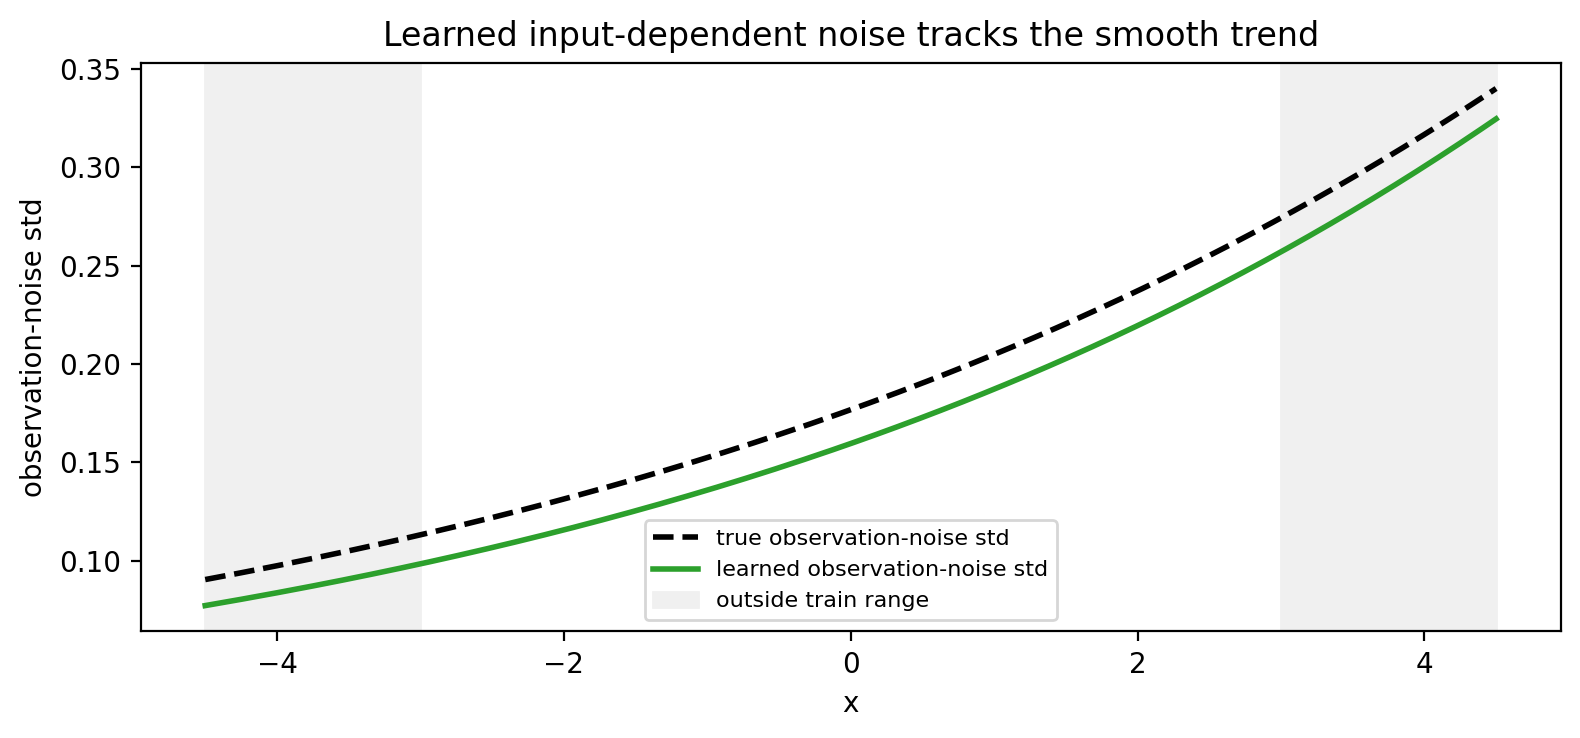
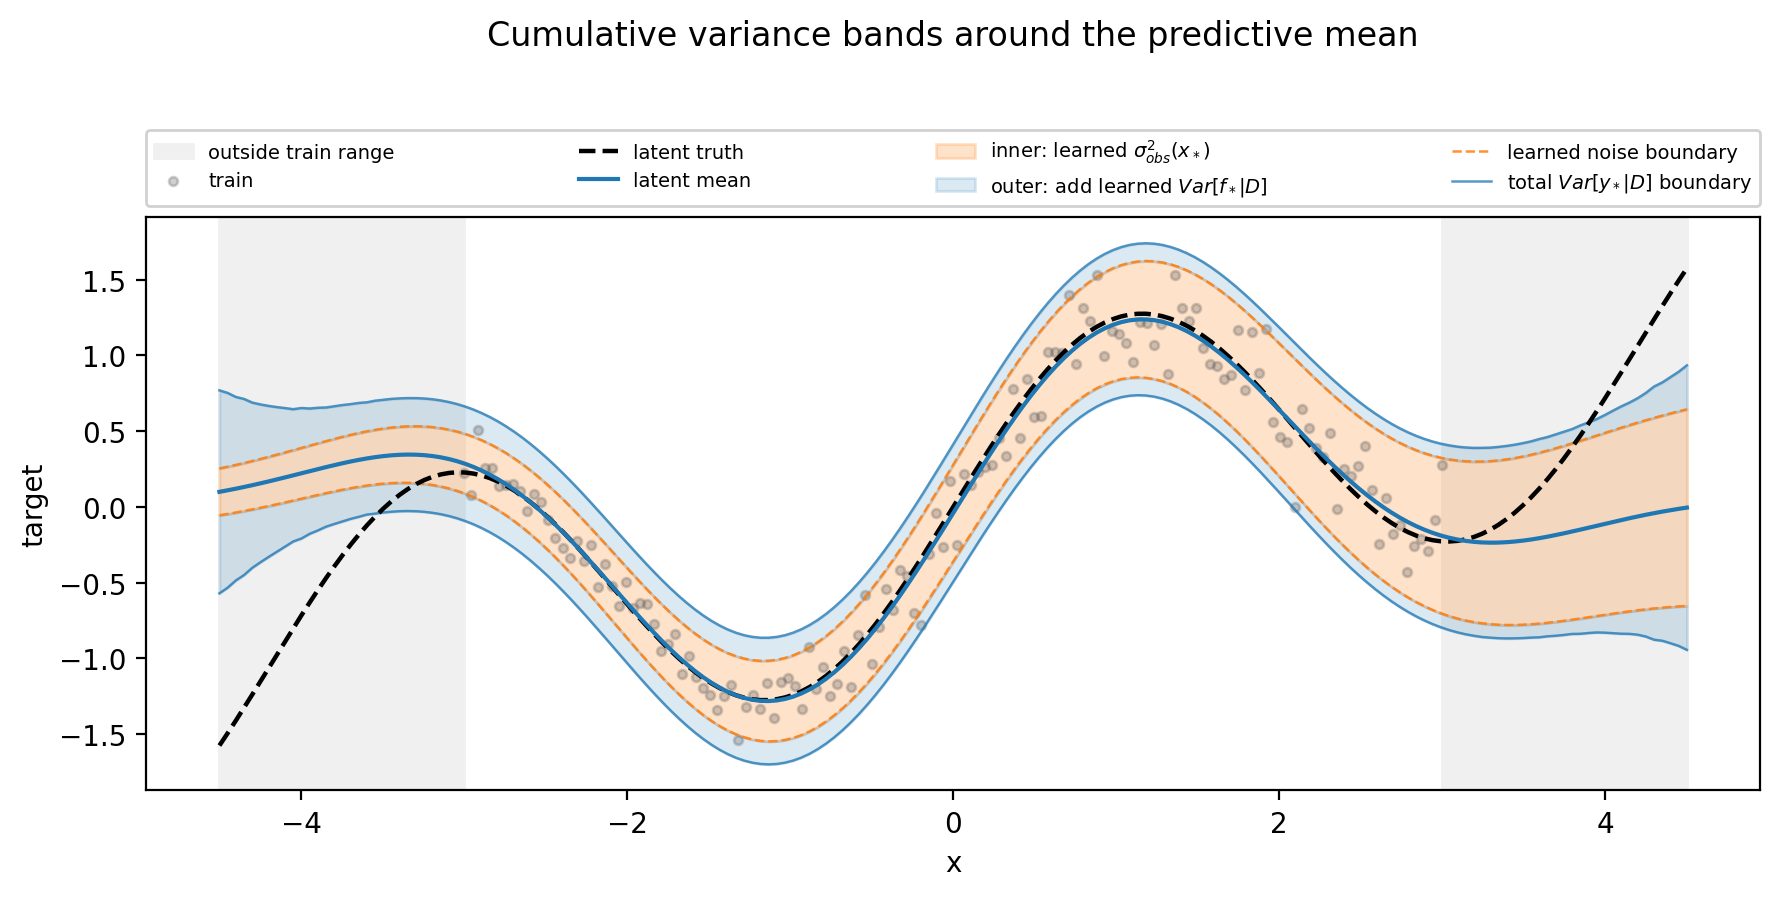
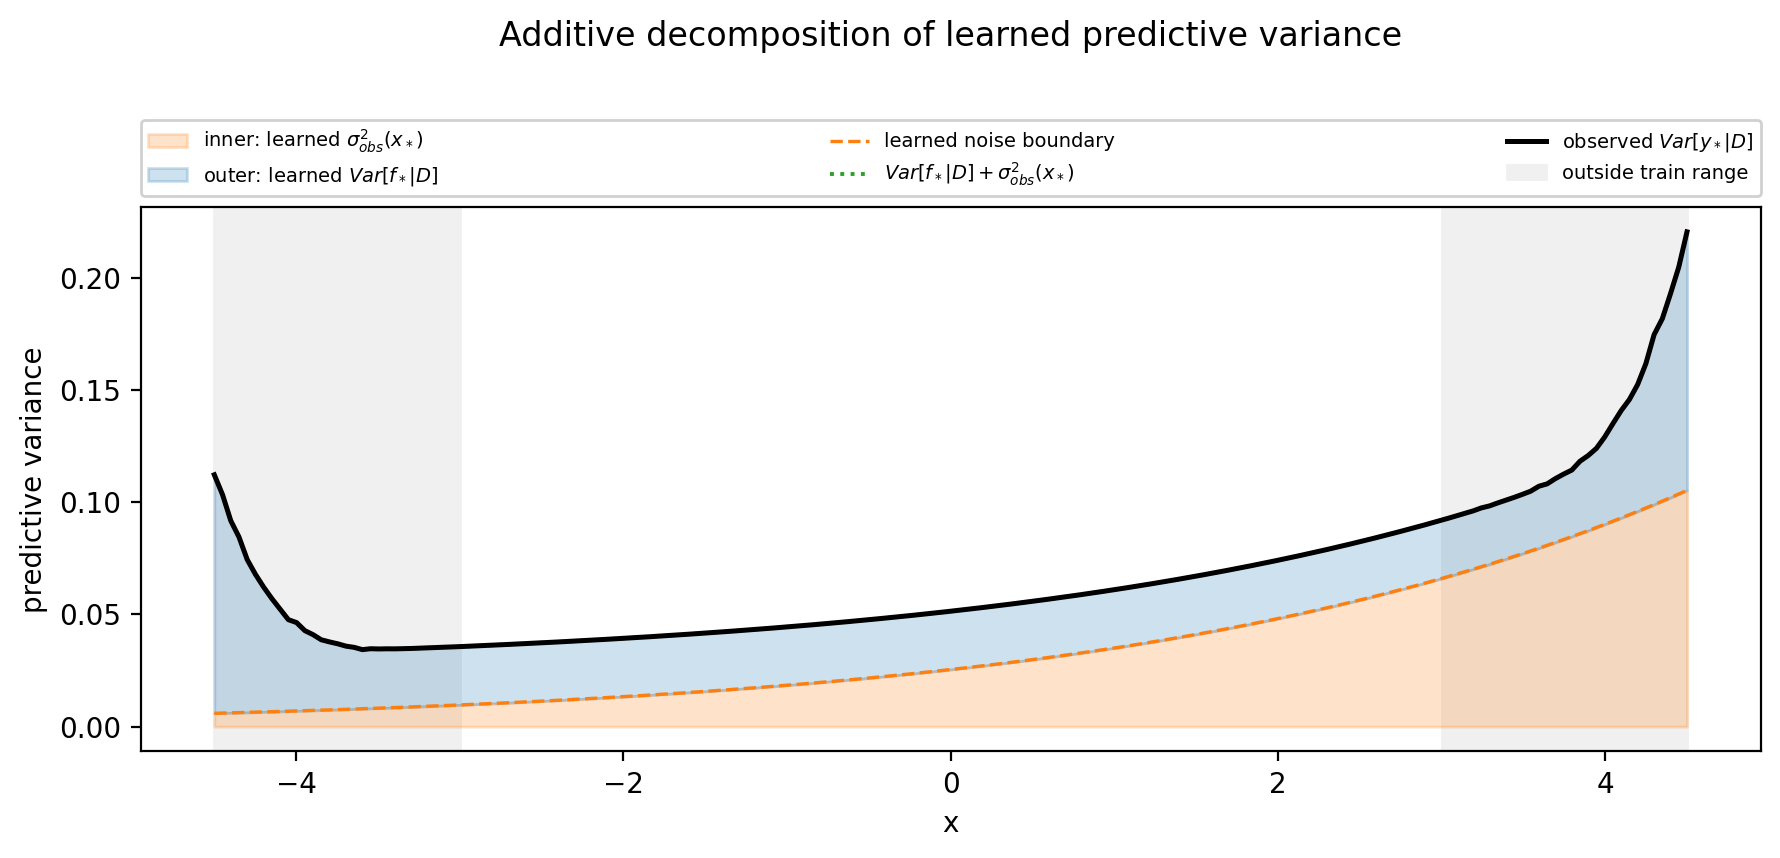

In [ ]:
from mojogp import RBF, SingleOutputGP

gp = SingleOutputGP(RBF())
train_result = gp.fit(
    X_train,
    y_train,
    noise_model="learned_input_dependent",
    noise_function="linear",
    initial_noise=float(np.mean(train_noise)),
    noise_regularization=0.005,
    max_iterations=50,
    learning_rate=0.03,
    method="materialized",
    progress=True,
)

latent = gp.predict_latent(X_test, variance_method="exact", progress=True)
observed = gp.predict_observed(X_test, variance_method="exact", progress=True)
learned_params = gp.get_learned_params()["noise_function_params"]
raw_noise = learned_params[0] + X_test[:, 0] * learned_params[1]
learned_noise = (np.logaddexp(0.0, raw_noise.astype(np.float64)) + 1e-6).astype(
    np.float32
)

predictive_mean_rmse = float(np.sqrt(np.mean((latent.mean - y_true) ** 2)))
noise_variance_rmse = float(np.sqrt(np.mean((learned_noise - test_noise) ** 2)))
noise_std_rmse = float(np.sqrt(np.mean((np.sqrt(learned_noise) - np.sqrt(test_noise)) ** 2)))
observed_variance_from_sum = latent.variance + learned_noise
observed_variance_gap = float(np.max(np.abs(observed.variance - observed_variance_from_sum)))
noise_interval_width = 2 * np.sqrt(learned_noise)
observed_interval_width = 2 * observed.std

fig_noise, learned_noise_ax = plt.subplots(figsize=(8, 3.8))
learned_noise_ax.plot(
    X_test[:, 0],
    np.sqrt(test_noise),
    "k--",
    linewidth=2,
    label="true observation-noise std",
)
learned_noise_ax.plot(
    X_test[:, 0],
    np.sqrt(learned_noise),
    color="tab:green",
    linewidth=2,
    label="learned observation-noise std",
)
learned_noise_ax.axvspan(-4.5, -3.0, color="0.94", zorder=-1)
learned_noise_ax.axvspan(3.0, 4.5, color="0.94", zorder=-1, label="outside train range")
learned_noise_ax.set_title("Learned input-dependent noise tracks the smooth trend")
learned_noise_ax.set_xlabel("x")
learned_noise_ax.set_ylabel("observation-noise std")
learned_noise_ax.legend(fontsize=8)
fig_noise.tight_layout()

fig_uncertainty, uncertainty_ax = plt.subplots(figsize=(9, 4.6))
uncertainty_ax.axvspan(-4.5, -3.0, color="0.94", zorder=-1)
uncertainty_ax.axvspan(3.0, 4.5, color="0.94", zorder=-1, label="outside train range")
uncertainty_ax.scatter(
    X_train[:, 0],
    y_train,
    s=10,
    alpha=0.28,
    color="0.35",
    label="train",
    zorder=3,
)
uncertainty_ax.plot(X_test[:, 0], y_true, "k--", linewidth=1.6, label="latent truth", zorder=4)
uncertainty_ax.plot(X_test[:, 0], latent.mean, color="tab:blue", label="latent mean", zorder=5)
uncertainty_ax.fill_between(
    X_test[:, 0],
    latent.mean - noise_interval_width,
    latent.mean + noise_interval_width,
    color="tab:orange",
    alpha=0.22,
    label=r"inner: learned $\sigma^2_{obs}(x_*)$",
    zorder=1,
)
uncertainty_ax.fill_between(
    X_test[:, 0],
    latent.mean + noise_interval_width,
    latent.mean + observed_interval_width,
    color="tab:blue",
    alpha=0.16,
    label=r"outer: add learned $Var[f_*|D]$",
    zorder=2,
)
uncertainty_ax.fill_between(
    X_test[:, 0],
    latent.mean - observed_interval_width,
    latent.mean - noise_interval_width,
    color="tab:blue",
    alpha=0.16,
    zorder=2,
)
uncertainty_ax.plot(
    X_test[:, 0],
    latent.mean - noise_interval_width,
    color="tab:orange",
    linestyle="--",
    linewidth=0.9,
    alpha=0.85,
    zorder=3,
)
uncertainty_ax.plot(
    X_test[:, 0],
    latent.mean + noise_interval_width,
    color="tab:orange",
    linestyle="--",
    linewidth=0.9,
    alpha=0.85,
    label="learned noise boundary",
    zorder=3,
)
uncertainty_ax.plot(
    X_test[:, 0],
    latent.mean - observed_interval_width,
    color="tab:blue",
    linewidth=0.9,
    alpha=0.75,
    label=r"total $Var[y_*|D]$ boundary",
    zorder=3,
)
uncertainty_ax.plot(
    X_test[:, 0],
    latent.mean + observed_interval_width,
    color="tab:blue",
    linewidth=0.9,
    alpha=0.75,
    zorder=3,
)
uncertainty_ax.set_title(
    "Cumulative variance bands around the predictive mean",
    pad=62,
)
uncertainty_ax.set_xlabel("x")
uncertainty_ax.set_ylabel("target")
uncertainty_ax.legend(
    fontsize=7,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.02, 1.0, 0.22),
    mode="expand",
    ncol=4,
    borderaxespad=0.0,
    framealpha=0.9,
)
fig_uncertainty.tight_layout()

fig_variance, variance_ax = plt.subplots(figsize=(9, 4.4))
variance_ax.fill_between(
    X_test[:, 0],
    0.0,
    learned_noise,
    color="tab:orange",
    alpha=0.22,
    label=r"inner: learned $\sigma^2_{obs}(x_*)$",
)
variance_ax.fill_between(
    X_test[:, 0],
    learned_noise,
    observed_variance_from_sum,
    color="tab:blue",
    alpha=0.22,
    label=r"outer: learned $Var[f_*|D]$",
)
variance_ax.plot(
    X_test[:, 0],
    learned_noise,
    color="tab:orange",
    linestyle="--",
    linewidth=1.2,
    label="learned noise boundary",
)
variance_ax.plot(
    X_test[:, 0],
    observed_variance_from_sum,
    color="tab:green",
    linestyle=":",
    linewidth=1.4,
    label=r"$Var[f_*|D] + \sigma^2_{obs}(x_*)$",
)
variance_ax.plot(
    X_test[:, 0],
    observed.variance,
    color="black",
    linewidth=1.8,
    label=r"observed $Var[y_*|D]$",
)
variance_ax.axvspan(-4.5, -3.0, color="0.94", zorder=-1)
variance_ax.axvspan(3.0, 4.5, color="0.94", zorder=-1, label="outside train range")
variance_ax.set_title("Additive decomposition of learned predictive variance", pad=58)
variance_ax.set_xlabel("x")
variance_ax.set_ylabel("predictive variance")
variance_ax.legend(
    fontsize=7,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.02, 1.0, 0.22),
    mode="expand",
    ncol=3,
    borderaxespad=0.0,
    framealpha=0.9,
)
fig_variance.tight_layout()

summary_rows = [
    {"Quantity": "Predictive mean RMSE vs latent truth", "Value": f"{predictive_mean_rmse:.4f}"},
    {"Quantity": "Noise variance RMSE vs true function", "Value": f"{noise_variance_rmse:.5f}"},
    {"Quantity": "Noise std RMSE vs true function", "Value": f"{noise_std_rmse:.5f}"},
    {"Quantity": "Mean true noise std", "Value": f"{float(np.mean(np.sqrt(test_noise))):.4f}"},
    {"Quantity": "Mean learned noise std", "Value": f"{float(np.mean(np.sqrt(learned_noise))):.4f}"},
    {"Quantity": "Mean learned latent GP std", "Value": f"{float(np.mean(latent.std)):.4f}"},
    {"Quantity": "Mean observed std", "Value": f"{float(np.mean(observed.std)):.4f}"},
    {"Quantity": "Max variance decomposition error", "Value": f"{observed_variance_gap:.8f}"},
    {"Quantity": "Learned raw-noise intercept", "Value": f"{float(learned_params[0]):.4f}"},
    {"Quantity": "Learned raw-noise slope", "Value": f"{float(learned_params[1]):.4f}"},
    {"Quantity": "Final NLL", "Value": f"{train_result.nll:.4f}"},
]

mo.vstack(
    [
        mo.mpl.interactive(fig_noise),
        mo.mpl.interactive(fig_uncertainty),
        mo.mpl.interactive(fig_variance),
        mo.ui.table(summary_rows, label="Learned input-dependent noise summary"),
    ]
)